In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

In [31]:
base_dir = '/Users/kimminseo/Downloads/ml/'
reddit_data_dir = os.path.join(base_dir, 'reddit_data/')

raw_comments_input_file = os.path.join(reddit_data_dir, 'reddit_wsb_comments_raw.csv')
refined_comments_output_file = os.path.join(reddit_data_dir, 'reddit_wsb_comments.csv')

comment_text_column = 'body'
input_timestamp_column_name = 'created_utc'

focused_start_date = '2020-10-01'
focused_end_date = '2022-02-28'

In [32]:
print(f"\n--- Inspecting Raw '{input_timestamp_column_name}' Column from '{raw_comments_input_file}' ---")

sample_rows_to_inspect = 1000

if not os.path.exists(raw_comments_input_file):
    print(f"Error: The raw comments file '{raw_comments_input_file}' was not found. Please check the path.")
else:
    try:
        df_raw_timestamp_sample = pd.read_csv(
            raw_comments_input_file,
            usecols=[input_timestamp_column_name, 'score', 'body'],
            nrows=sample_rows_to_inspect,
            low_memory=False
        )

        print(f"\nFirst {sample_rows_to_inspect} rows of raw data for relevant columns:")
        print(df_raw_timestamp_sample.head(20))

        print(f"\nData type of raw '{input_timestamp_column_name}' column in this sample:")
        print(df_raw_timestamp_sample[input_timestamp_column_name].dtype)

        print(f"\nTop 20 unique values and their counts for raw '{input_timestamp_column_name}' column:")
        print(df_raw_timestamp_sample[input_timestamp_column_name].value_counts(dropna=False).head(20))

        print(f"\nAttempting to convert '{input_timestamp_column_name}' to numeric (Unix timestamp candidate):")
        numeric_ts_sample = pd.to_numeric(df_raw_timestamp_sample[input_timestamp_column_name], errors='coerce')
        print(f"Number of non-numeric values (converted to NaN): {numeric_ts_sample.isna().sum()} out of {len(numeric_ts_sample)}")
        print("Sample of numeric conversion results:")
        print(numeric_ts_sample.head(20))

        print(f"\nAttempting to convert '{input_timestamp_column_name}' to datetime (string parse candidate):")
        datetime_ts_sample = pd.to_datetime(df_raw_timestamp_sample[input_timestamp_column_name], errors='coerce')
        print(f"Number of non-datetime values (converted to NaT): {datetime_ts_sample.isna().sum()} out of {len(datetime_ts_sample)}")
        print("Sample of datetime conversion results:")
        print(datetime_ts_sample.head(20))

    except Exception as e:
        print(f"An error occurred during raw timestamp inspection: {e}")
        print("Please ensure the file path and column name are correct.")


--- Inspecting Raw 'created_utc' Column from '/Users/kimminseo/Downloads/ml/reddit_data/reddit_wsb_comments_raw.csv' ---

First 1000 rows of raw data for relevant columns:
                                                 body  created_utc  score
0   We’re retarded and claim to be often. If you l...   1585123910      1
1                                                 Yes   1585123909      1
2                     markets been open for 13 min...   1585123905      1
3   Spy can fuck around all it wants just as long ...   1585123901      1
4                                           [removed]   1585123897      1
5                       you lost me at "bulls fucked"   1585123896      1
6   I wonder if the same people who short TSLA but...   1585123895      1
7                             **Glory to Arstotzka!**   1585123891      1
8   it’s just a bull trap it’s just a bull trap it...   1585123890      1
9            Yes, it's reliable. Gold is crashing lol   1585123889      1
10  Ask him f

In [33]:
print(f"\n--- Starting Robust Refinement of '{raw_comments_input_file}' to '{refined_comments_output_file}' ---")

max_rows_to_process = 30000000

if not os.path.exists(raw_comments_input_file):
    print(f"Error: The raw comments file '{raw_comments_input_file}' was not found. Cannot proceed with refinement.")
else:
    try:
        chunksize = 100000
        temp_df_chunks = []

        print(f"Loading raw comments in chunks (up to {max_rows_to_process} rows) and performing initial cleaning and type conversion...")
        columns_to_load_raw = [input_timestamp_column_name, 'score', 'author', comment_text_column]

        raw_reader = pd.read_csv(raw_comments_input_file,
                                 usecols=columns_to_load_raw,
                                 chunksize=chunksize,
                                 low_memory=False,
                                 nrows=max_rows_to_process)

        for i, chunk in enumerate(raw_reader):
            chunk['score'] = pd.to_numeric(chunk['score'], errors='coerce')
            chunk['timestamp_utc'] = pd.to_datetime(chunk[input_timestamp_column_name], unit='s', errors='coerce')

            if input_timestamp_column_name != 'timestamp_utc':
                chunk.drop(columns=[input_timestamp_column_name], inplace=True, errors='ignore')

            initial_chunk_len = len(chunk)
            chunk.dropna(subset=[comment_text_column, 'timestamp_utc', 'score'], inplace=True)
            chunk = chunk[chunk[comment_text_column].astype(str).str.strip() != '']

            if len(chunk) == 0:
                print(f"Chunk {i+1}: {initial_chunk_len} rows -> 0 clean rows (entire chunk invalid after cleaning).")
                continue

            print(f"Chunk {i+1}: {initial_chunk_len} rows -> {len(chunk)} clean rows.")
            temp_df_chunks.append(chunk)

        if not temp_df_chunks:
            print("\nNo valid chunks processed. Resulting DataFrame will be empty.")
            df_comments_final_refined = pd.DataFrame()
        else:
            df_comments_pre_filter = pd.concat(temp_df_chunks, ignore_index=True)
            print(f"\nInitial chunk-based cleaning complete. Total comments pre-filter: {len(df_comments_pre_filter)}")

            if not pd.api.types.is_datetime64_any_dtype(df_comments_pre_filter['timestamp_utc']):
                print("Error: 'timestamp_utc' column is not datetime after initial cleaning. Cannot filter by date.")
                df_comments_final_refined = pd.DataFrame()
            else:
                df_comments_temp_indexed = df_comments_pre_filter.set_index('timestamp_utc').sort_index()
                df_comments_final_refined = df_comments_temp_indexed.loc[focused_start_date:focused_end_date].reset_index()
                print(f"Filtered to focused period ({focused_start_date} to {focused_end_date}). Final clean comments: {len(df_comments_final_refined)}")

                print("\nFinal Refined Comments (First 5 rows):")
                print(df_comments_final_refined.head())
                print("\nFinal Refined Comments Info:")
                df_comments_final_refined.info()

        if not df_comments_final_refined.empty:
            df_comments_final_refined.to_csv(refined_comments_output_file, index=False)
            print(f"\nThoroughly refined comments saved to: '{refined_comments_output_file}'")
        else:
            print("\nRefined comments DataFrame is empty after cleaning and filtering. No file saved.")

    except Exception as e:
        print(f"An unexpected error occurred during raw comments refinement: {e}")
        print("This might indicate issues with file corruption or unexpected data formats.")
        print("Please review the error message and the raw data around the problematic chunks.")


--- Starting Robust Refinement of '/Users/kimminseo/Downloads/ml/reddit_data/reddit_wsb_comments_raw.csv' to '/Users/kimminseo/Downloads/ml/reddit_data/reddit_wsb_comments.csv' ---
Loading raw comments in chunks (up to 30000000 rows) and performing initial cleaning and type conversion...
Chunk 1: 100000 rows -> 99997 clean rows.
Chunk 2: 100000 rows -> 100000 clean rows.
Chunk 3: 100000 rows -> 99999 clean rows.
Chunk 4: 100000 rows -> 99997 clean rows.
Chunk 5: 100000 rows -> 99999 clean rows.
Chunk 6: 100000 rows -> 99999 clean rows.
Chunk 7: 100000 rows -> 99999 clean rows.
Chunk 8: 100000 rows -> 99998 clean rows.
Chunk 9: 100000 rows -> 99997 clean rows.
Chunk 10: 100000 rows -> 99999 clean rows.
Chunk 11: 100000 rows -> 99998 clean rows.
Chunk 12: 100000 rows -> 99998 clean rows.
Chunk 13: 100000 rows -> 100000 clean rows.
Chunk 14: 100000 rows -> 99999 clean rows.
Chunk 15: 100000 rows -> 99999 clean rows.
Chunk 16: 100000 rows -> 99999 clean rows.
Chunk 17: 100000 rows -> 9999


--- Generating Report Figure 2: Daily Comment Volume in Refined Dataset ---
Loaded 3907758 refined comments for plotting.


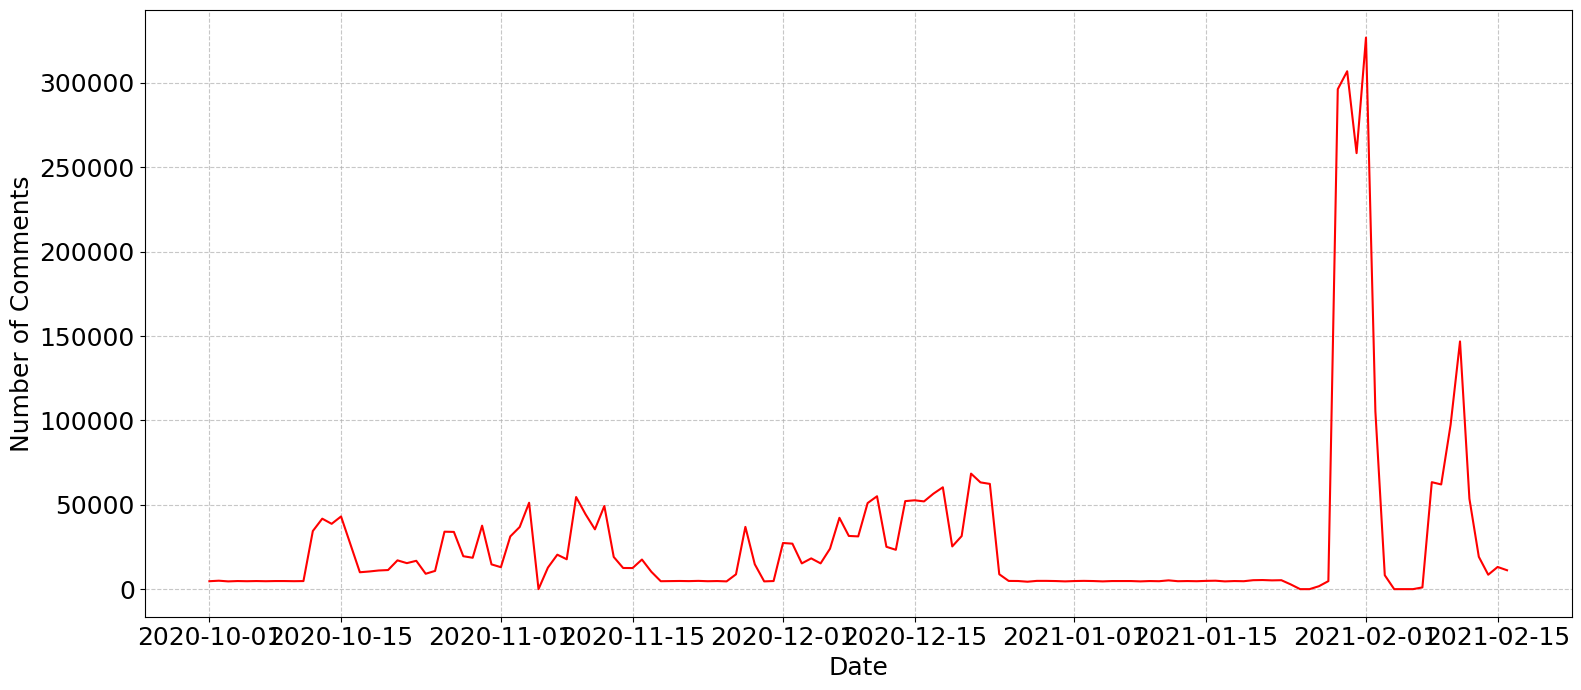


Figure 2 generated for range 2020-10-01 00:34:00 to 2021-02-16 14:02:47. Save this image for your report.


In [34]:
print("\n--- Generating Report Figure 2: Daily Comment Volume in Refined Dataset ---")

focused_start_date = '2020-09-29'
focused_end_date = '2022-02-14'

if not os.path.exists(refined_comments_output_file):
    print(f"Error: Refined comments file not found at '{refined_comments_output_file}'. Please ensure your comment refinement process was completed and saved this file.")
else:
    try:
        df_refined_comments = pd.read_csv(refined_comments_output_file)
        df_refined_comments['timestamp_utc'] = pd.to_datetime(df_refined_comments['timestamp_utc'])

        df_refined_comments_plot = df_refined_comments.set_index('timestamp_utc').loc[focused_start_date:focused_end_date].reset_index().sort_values('timestamp_utc')

        if not df_refined_comments_plot.empty:
            num_comments_refined = len(df_refined_comments_plot)
            print(f"Loaded {num_comments_refined} refined comments for plotting.")

            daily_comment_counts = df_refined_comments_plot.set_index('timestamp_utc').resample('D').size().reset_index(name='Comment Count')

            plt.figure(figsize=(16, 7))
            sns.lineplot(x='timestamp_utc', y='Comment Count', data=daily_comment_counts, color='red')
            plt.xlabel('Date', fontsize=18)
            plt.ylabel('Number of Comments', fontsize=18)
            plt.tick_params(axis='both', which='major', labelsize=18)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()

            print(f"\nFigure 2 generated for range {df_refined_comments_plot['timestamp_utc'].min()} to {df_refined_comments_plot['timestamp_utc'].max()}. Save this image for your report.")

        else:
            print(f"Refined comments DataFrame is empty after filtering to ({focused_start_date} - {focused_end_date}). No visualization generated.")

    except Exception as e:
        print(f"An error occurred while loading or visualizing the refined comments file for Figure 2: {e}")
        print("Please ensure the saved CSV is valid and the 'timestamp_utc' column is present.")


--- Generating Report Figure 2: Daily Comment Volume in Refined Dataset ---
Loaded 3907758 refined comments for plotting.


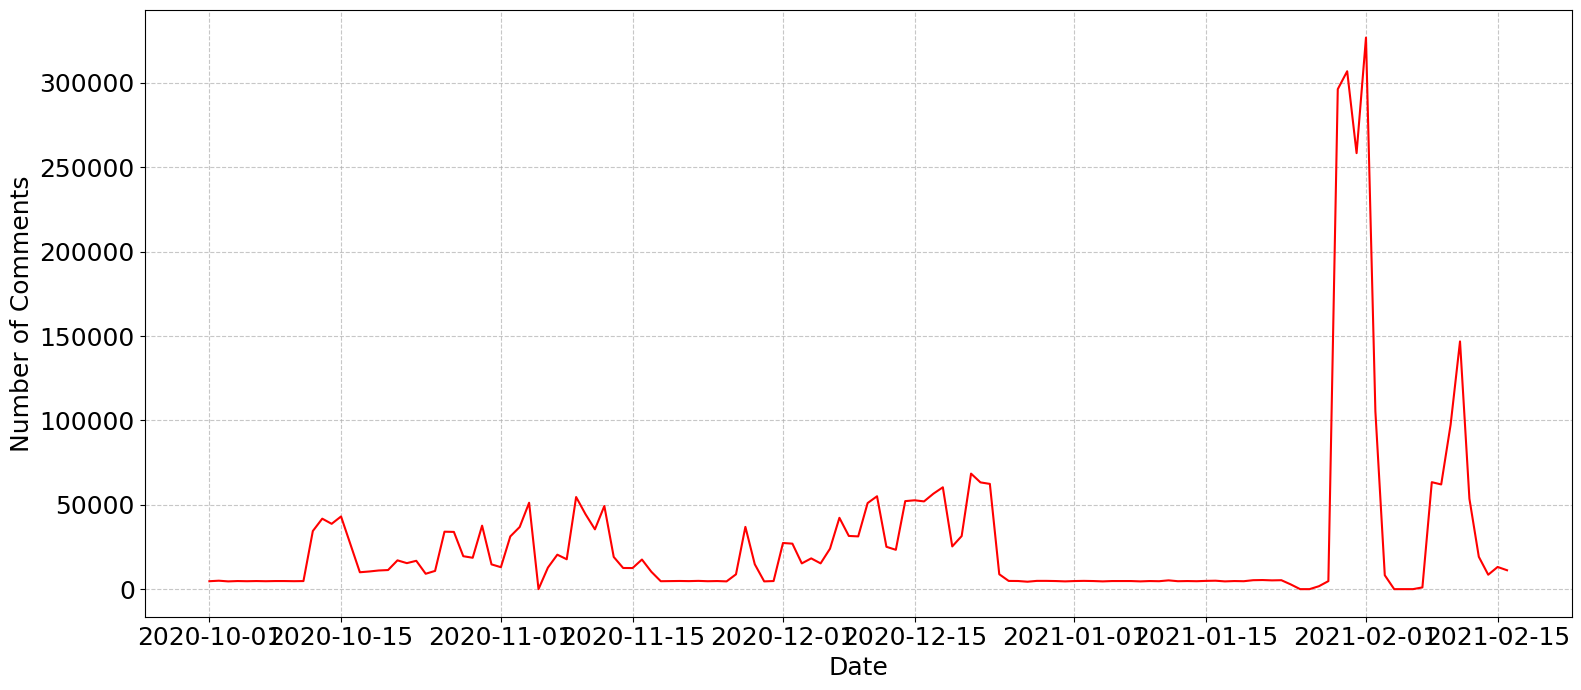


Figure 2 generated for range 2020-10-01 00:34:00 to 2021-02-16 14:02:47. Save this image for your report.


In [35]:
print("\n--- Generating Report Figure 2: Daily Comment Volume in Refined Dataset ---")

focused_start_date = '2020-09-29'
focused_end_date = '2022-02-14'

if not os.path.exists(refined_comments_output_file):
    print(f"Error: Refined comments file not found at '{refined_comments_output_file}'. Please ensure your comment refinement process was completed and saved this file.")
else:
    try:
        df_refined_comments = pd.read_csv(refined_comments_output_file)
        df_refined_comments['timestamp_utc'] = pd.to_datetime(df_refined_comments['timestamp_utc'])

        df_refined_comments_plot = df_refined_comments.set_index('timestamp_utc').loc[focused_start_date:focused_end_date].reset_index().sort_values('timestamp_utc')

        if not df_refined_comments_plot.empty:
            num_comments_refined = len(df_refined_comments_plot)
            print(f"Loaded {num_comments_refined} refined comments for plotting.")

            daily_comment_counts = df_refined_comments_plot.set_index('timestamp_utc').resample('D').size().reset_index(name='Comment Count')

            plt.figure(figsize=(16, 7))
            sns.lineplot(x='timestamp_utc', y='Comment Count', data=daily_comment_counts, color='red')
            plt.xlabel('Date', fontsize=18)
            plt.ylabel('Number of Comments', fontsize=18)
            plt.tick_params(axis='both', which='major', labelsize=18)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()

            print(f"\nFigure 2 generated for range {df_refined_comments_plot['timestamp_utc'].min()} to {df_refined_comments_plot['timestamp_utc'].max()}. Save this image for your report.")

        else:
            print(f"Refined comments DataFrame is empty after filtering to ({focused_start_date} - {focused_end_date}). No visualization generated.")

    except Exception as e:
        print(f"An error occurred while loading or visualizing the refined comments file for Figure 2: {e}")
        print("Please ensure the saved CSV is valid and the 'timestamp_utc' column is present.")